In [25]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('activemq-5.0.0.csv')

df.head()

,File,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,...,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE,HeuBug,HeuBugCount,RealBug,RealBugCount
0,activemq-console/src/main/java/org/apache/acti...,0,10,171,5,0,2,0,18,2,...,1.00000,1.0,0,1,1,0,False,0,False,0
1,activemq-console/src/main/java/org/apache/acti...,0,8,123,5,0,1,1,15,3,...,0.98374,0.5,0,1,2,1,False,0,False,0
2,activemq-console/src/main/java/org/apache/acti...,0,7,136,5,0,1,1,16,2,...,1.00000,1.0,0,1,1,0,False,0,False,0
3,activemq-console/src/main/java/org/apache/acti...,0,29,241,17,0,4,5,29,9,...,1.00000,1.0,0,1,1,0,False,0,False,0
4,activemq-console/src/main/java/org/apache/acti...,0,24,212,17,0,3,5,26,8,...,1.00000,1.0,0,1,1,0,False,0,False,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   File                       1884 non-null   object 
 1   CountDeclMethodPrivate     1884 non-null   int64  
 2   AvgLineCode                1884 non-null   int64  
 3   CountLine                  1884 non-null   int64  
 4   MaxCyclomatic              1884 non-null   int64  
 5   CountDeclMethodDefault     1884 non-null   int64  
 6   AvgEssential               1884 non-null   int64  
 7   CountDeclClassVariable     1884 non-null   int64  
 8   SumCyclomaticStrict        1884 non-null   int64  
 9   AvgCyclomatic              1884 non-null   int64  
 10  AvgLine                    1884 non-null   int64  
 11  CountDeclClassMethod       1884 non-null   int64  
 12  AvgLineComment             1884 non-null   int64  
 13  AvgCyclomaticModified      1884 non-null   int64

In [27]:
df = df.drop(columns=['HeuBug', 'HeuBugCount', 'RealBugCount'])

In [28]:
df.shape

(1884, 67)

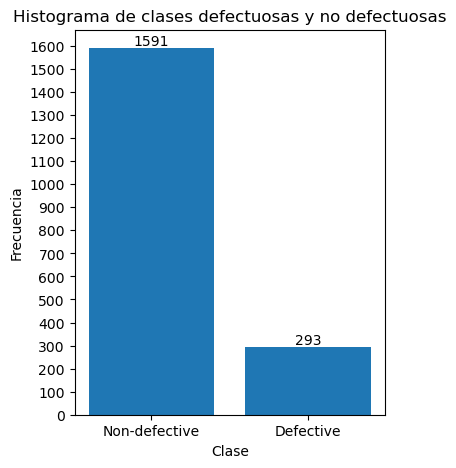

In [29]:
import matplotlib.pyplot as plt
#Defective and Non-defective Class histogram

# Count the occurrences of each class
class_counts = df['RealBug'].value_counts()

# Plot the histogram with increased height
plt.figure(figsize=(4, 5))
bars = plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Histograma de clases defectuosas y no defectuosas')
plt.xticks([0, 1], ['Non-defective', 'Defective'])

# show more numbers in frequency (y axis)
plt.gca().set_yticks(range(0, class_counts.max() + 50, 100))

# Add value labels on top of bars
plt.bar_label(bars, labels=[f'{val}' for val in class_counts.values])

# show the grid
# plt.grid(axis='y')
plt.show()


In [30]:
class_counts

RealBug
False    1591
True      293
Name: count, dtype: int64

<Axes: xlabel='RealBug', ylabel='CountLineCode'>

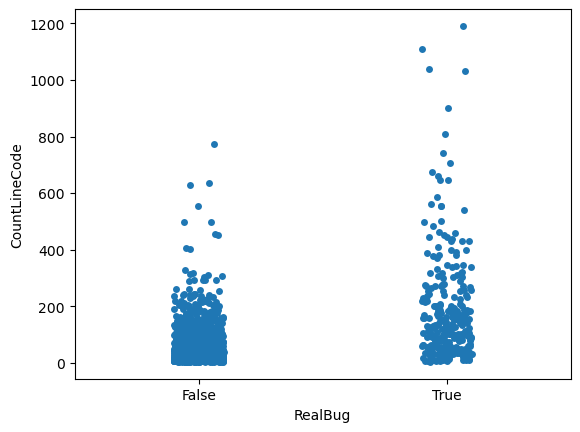

In [31]:
# Dispersion plot of class Defective
import seaborn as sns

sns.stripplot(x='RealBug', y='CountLineCode', data=df, jitter=True)

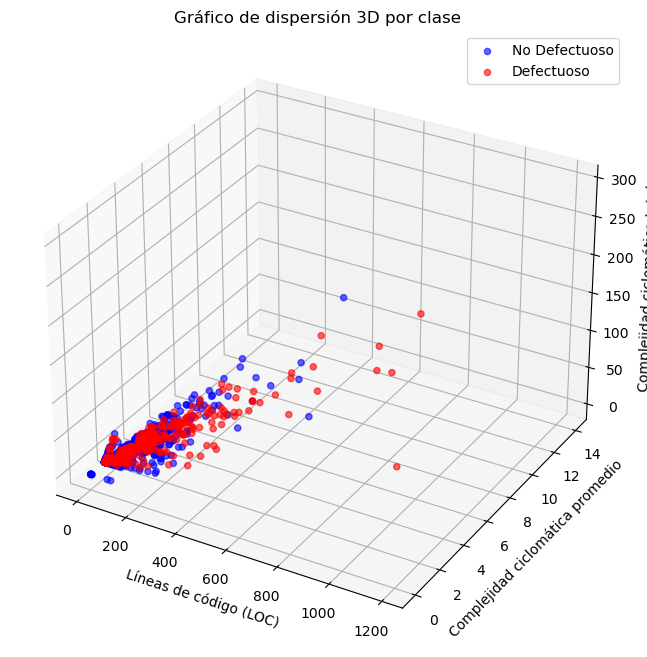

In [32]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# Separar por clase
defective = df[df['RealBug'] == 1]
non_defective = df[df['RealBug'] == 0]

# Graficar cada clase con diferente color
ax.scatter(non_defective['CountLineCode'], 
           non_defective['AvgCyclomatic'], 
           non_defective['SumCyclomatic'],
           c='blue', label='No Defectuoso', alpha=0.6)

ax.scatter(defective['CountLineCode'], 
           defective['AvgCyclomatic'], 
           defective['SumCyclomatic'],
           c='red', label='Defectuoso', alpha=0.6)

ax.set_xlabel('Líneas de código (LOC)')
ax.set_ylabel('Complejidad ciclomática promedio')
ax.set_zlabel('Complejidad ciclomática total')
ax.set_title('Gráfico de dispersión 3D por clase')
ax.legend()

plt.show()

## Preprocesamiento

- isNull / Missing values
- Duplicados
- Outlaiers ( no porque el metodo HCBOU de balanceo no lo recomienda)
- Particion Train/Test
- Transformación de los datos - Normalización/Estandarización (StandarScaler)
- Balanceo de clases - HCBOU
- Seleccion de caracteristicas (arbol de decision - CABOOST) 
- Reduccion de Dimensionalidad (PCA)

### Missing Values

In [33]:
df.isnull().sum()

File                      0
CountDeclMethodPrivate    0
AvgLineCode               0
CountLine                 0
MaxCyclomatic             0
                         ..
MINOR_COMMIT              0
MINOR_LINE                0
MAJOR_COMMIT              0
MAJOR_LINE                0
RealBug                   0
Length: 67, dtype: int64

### Duplicated

In [34]:
df.duplicated().sum()

0

### Split Train/Test 80/20

In [35]:
# split train and test
from sklearn.model_selection import train_test_split

X = df.drop(columns=['RealBug'])
y = df['RealBug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [36]:
print(X_train.shape)
print(X_test.shape)

(1507, 66)
(377, 66)


### Normalización

In [37]:
from sklearn.preprocessing import StandardScaler

X_train_numeric = X_train.select_dtypes(include=['float64', 'int64'])
scaler = StandardScaler()
X_train_numeric_scaled = pd.DataFrame(scaler.fit_transform(X_train_numeric), columns=X_train_numeric.columns)

In [38]:
X_train_numeric.describe()

,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,AvgLine,...,ADEV,DDEV,Added_lines,Del_lines,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,...,1507.00000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,0.251493,6.670869,133.593232,2.939615,0.707366,1.063039,0.653616,15.506967,1.497014,9.166556,...,2.85136,1.222960,45.778368,40.039814,0.753385,0.930348,0.000664,2.009954,1.222296,0.325813
std,0.996569,6.124795,157.740734,3.412685,3.355235,0.333012,1.505895,25.008958,0.976734,8.010003,...,2.03043,0.454493,94.399612,85.170299,0.196911,0.146068,0.025760,0.810313,0.452623,0.599372
min,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.00000,1.000000,1.000000,0.000000,0.340000,0.333333,0.000000,1.000000,1.000000,0.000000
25%,0.000000,3.000000,51.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000,4.000000,...,2.00000,1.000000,4.000000,4.000000,0.571429,1.000000,0.000000,1.000000,1.000000,0.000000
50%,0.000000,5.000000,95.000000,2.000000,0.000000,1.000000,0.000000,7.000000,1.000000,7.000000,...,2.00000,1.000000,16.000000,14.000000,0.750000,1.000000,0.000000,2.000000,1.000000,0.000000
75%,0.000000,8.000000,149.000000,4.000000,0.000000,1.000000,1.000000,17.000000,2.000000,11.000000,...,3.00000,1.000000,47.000000,38.000000,0.973378,1.000000,0.000000,3.000000,1.000000,1.000000
max,21.000000,63.000000,2075.000000,56.000000,44.000000,4.000000,20.000000,301.000000,14.000000,75.000000,...,23.00000,4.000000,1402.000000,1326.000000,1.000000,1.000000,1.000000,5.000000,4.000000,4.000000


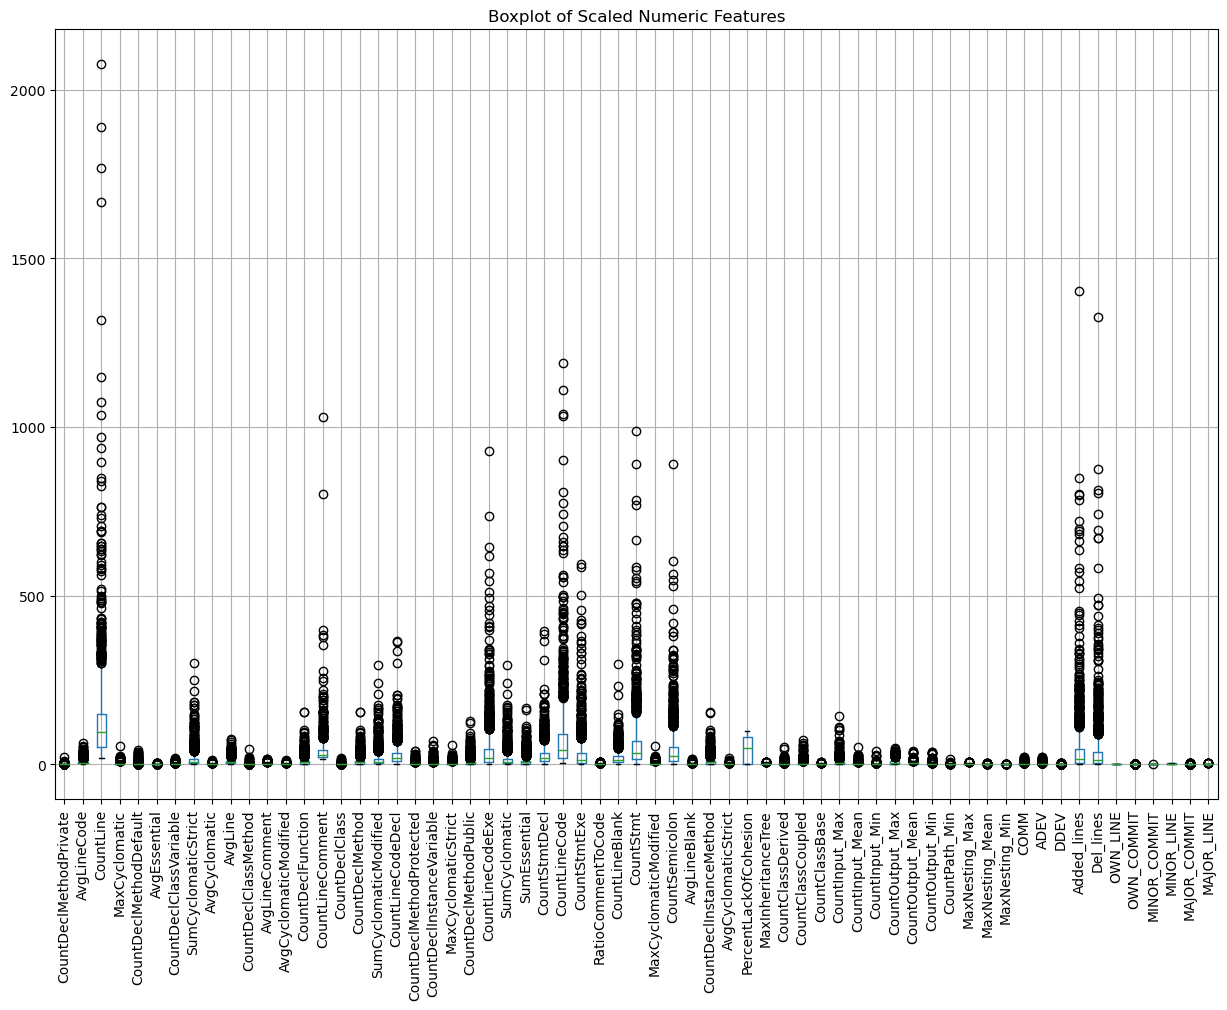

In [39]:
plt.figure(figsize=(15, 10))
X_train_numeric.drop(columns=['CountPath_Max', 'CountPath_Mean']).boxplot()
plt.title('Boxplot of Scaled Numeric Features')
plt.xticks(rotation=90)
plt.show()

In [40]:
X_train_numeric_scaled.describe()

,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,AvgLine,...,ADEV,DDEV,Added_lines,Del_lines,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE
count,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,...,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03,1.507000e+03
mean,4.714948e-17,-5.657938e-17,-8.958402e-17,-3.889832e-17,2.121727e-17,-1.885979e-16,4.714948e-17,9.429897e-18,-1.720956e-16,2.003853e-17,...,1.414485e-17,-8.722655e-17,-5.657938e-17,1.414485e-17,6.600928e-17,7.543918e-17,-2.357474e-18,-1.355548e-16,1.155162e-16,-2.003853e-17
std,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,...,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00,1.000332e+00
min,-2.524426e-01,-1.089519e+00,-7.203652e-01,-8.616650e-01,-2.108945e-01,-3.193250e+00,-4.341825e-01,-6.202623e-01,-1.533183e+00,-1.144768e+00,...,-9.121097e-01,-4.907301e-01,-4.745065e-01,-4.702708e-01,-2.100044e+00,-4.088592e+00,-2.576840e-02,-1.246788e+00,-4.912911e-01,-5.437708e-01
25%,-2.524426e-01,-5.995446e-01,-5.237750e-01,-5.685433e-01,-2.108945e-01,-1.893625e-01,-4.341825e-01,-5.002655e-01,-5.090221e-01,-6.452271e-01,...,-4.194397e-01,-4.907301e-01,-4.427162e-01,-4.232905e-01,-9.243602e-01,4.770033e-01,-2.576840e-02,-1.246788e+00,-4.912911e-01,-5.437708e-01
50%,-2.524426e-01,-2.728947e-01,-2.447436e-01,-2.754216e-01,-2.108945e-01,-1.893625e-01,-4.341825e-01,-3.402697e-01,-5.090221e-01,-2.705711e-01,...,-4.194397e-01,-4.907301e-01,-3.155548e-01,-3.058397e-01,-1.719640e-02,4.770033e-01,-2.576840e-02,-1.228766e-02,-4.912911e-01,-5.437708e-01
75%,-2.524426e-01,2.170802e-01,9.770389e-02,3.108218e-01,-2.108945e-01,-1.893625e-01,2.300947e-01,5.971973e-02,5.151385e-01,2.289703e-01,...,7.323031e-02,-4.907301e-01,1.294537e-02,-2.395778e-02,1.117588e+00,4.770033e-01,-2.576840e-02,1.222213e+00,-4.912911e-01,1.125196e+00
max,2.082685e+01,9.199953e+00,1.231167e+01,1.555315e+01,1.290729e+01,8.822301e+00,1.285136e+01,1.141942e+01,1.280507e+01,8.221632e+00,...,9.926630e+00,6.112219e+00,1.437158e+01,1.510370e+01,1.252833e+00,4.770033e-01,3.880722e+01,3.691214e+00,6.138939e+00,6.132095e+00


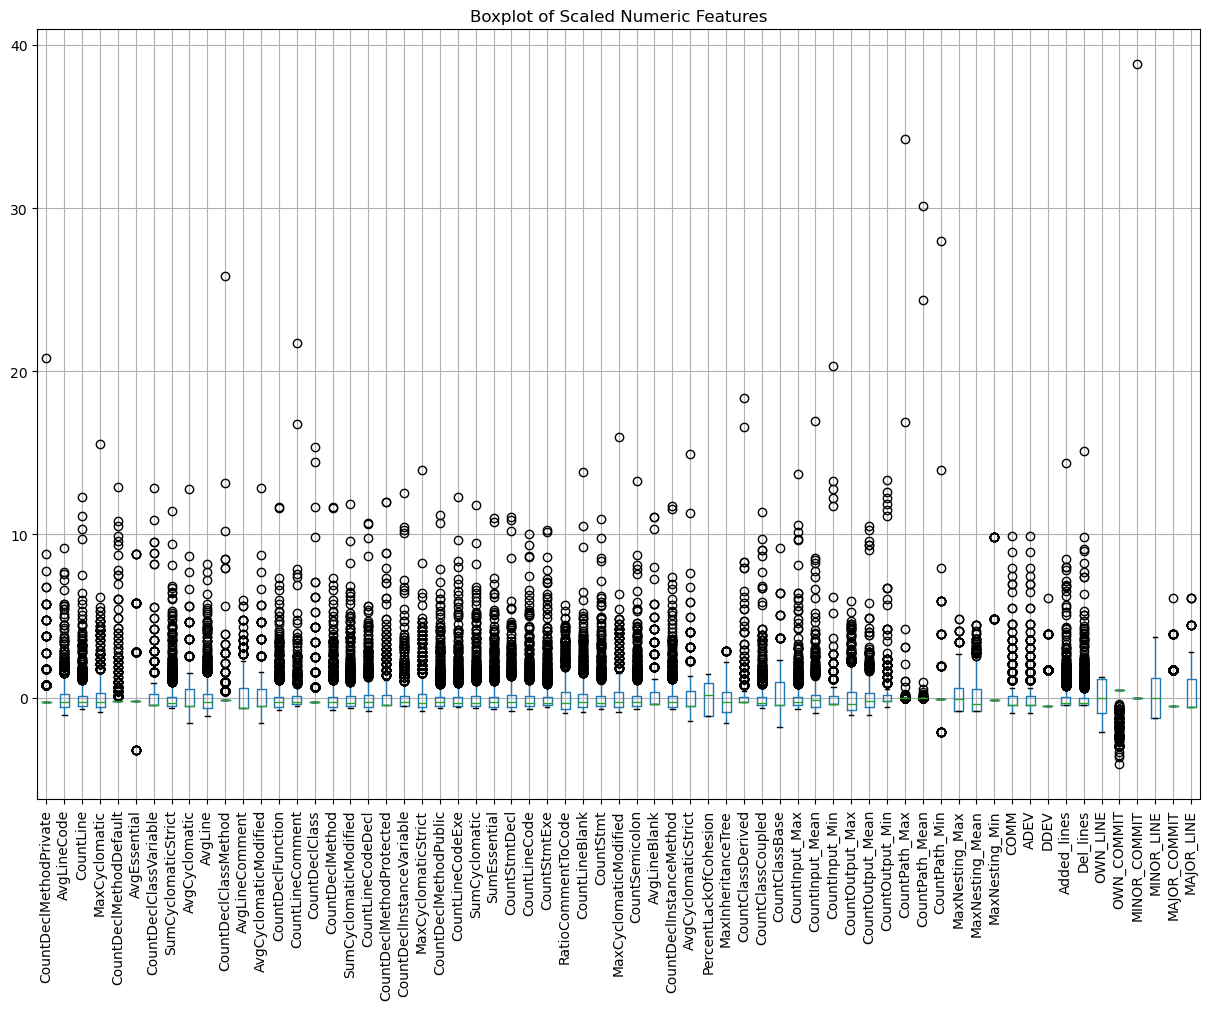

In [41]:
plt.figure(figsize=(15, 10))
X_train_numeric_scaled.boxplot()
plt.title('Boxplot of Scaled Numeric Features')
plt.xticks(rotation=90)
plt.show()